In [1]:
# Source - https://stackoverflow.com/q/64613706
# Posted by rgov
# Retrieved 2026-02-10, License - CC BY-SA 4.0

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

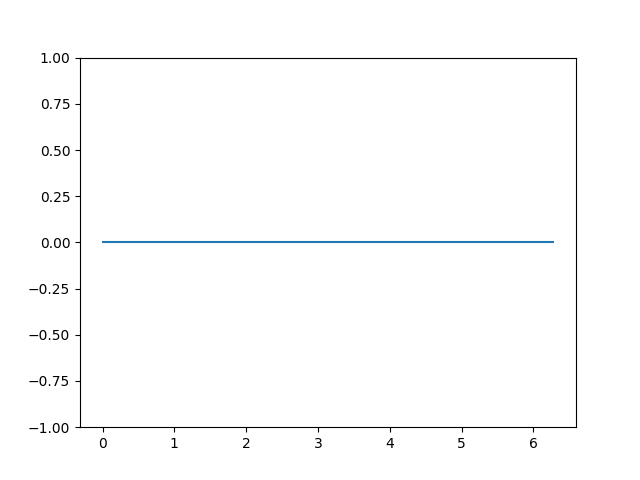

In [6]:

fig, ax = plt.subplots()
x = np.arange(0, 2*np.pi, 0.01)
line, = ax.plot(x, np.zeros(np.shape(x)))
ax.set_ylim(-1.0, 1.0)

class State_anim:
    def __init__(self, line, x0):
         self.line = line
         self.x = np.ones(len(x0))

    def init_plot(self):
        self.line.set_ydata(np.zeros(np.shape(self.x)))
        return self.line,

    def step(self, u, i):
        y = u*np.linspace(-1, 1, len(self.x))
        np.disp(y)
        self.x = y
        return y

    def animate(self, i):
        u = np.sin(0.05*i)
        y = self.step(u, i)
        self.line.set_ydata(y)  # update the data.
        return self.line,

state = State_anim(line, x0 = x)
ani = animation.FuncAnimation(fig, 
                              state.animate, 
                              init_func=state.init_plot, 
                              interval=5, 
                              blit=True, 
                              save_count=50)

# plt.show()


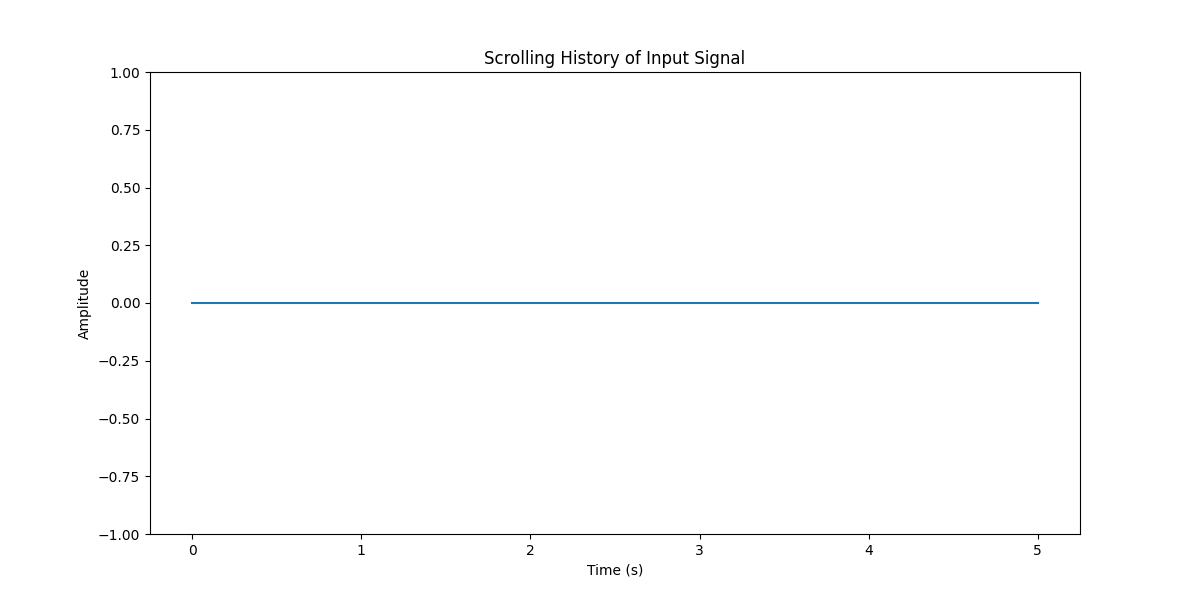

In [2]:
plt.close("all") # Close all previous figures to avoid overlap
window_length = 5 # seconds
dt = 0.1 # seconds

class Past_inputs_anim: #this class gathers the past inputs of "u" and plots them
    def __init__(self, line, window_length = 10, dt = 0.1):
         self.line = line
         self.state = 1 # Initial state, can be modified as needed
         self.dt = dt
         self.ptr = 0 # Pointer to the current position in the history array
         self.window_samples = int(window_length / dt) # Number of samples in the window
         self.N = self.window_samples # Number of past inputs to keep track of
         self.history = np.zeros(self.N) # Initialize history with zeros

    def init_plot(self):
        self.line.set_ydata(np.empty(self.N))
        return self.line,

    def step(self, u):
        # Simple state update: new state is a combination of the previous state and the new input
        output = self.state*0.1 + u*0.5
        self.state = output
        return output
    
    def update_History(self, u):
        # Shift history to the left and add new input at the end
        # self.history = np.roll(self.history, -1) # Shift history to the right
        # self.history[-1] = self.step(u) # Add new input at the beginning

        self.history[self.ptr] = self.step(u) # Add new input at the current pointer position
        self.ptr = (self.ptr + 1) % self.N # Move pointer and wrap
        # Create y-array in chronological order
        y_full = np.concatenate((self.history[self.ptr:], self.history[:self.ptr]))
        # Return only the last "window_samples" points
        y_window = y_full[-self.window_samples:]
        return y_window

    def animate(self, i):
        u = np.sin(0.05*i)
        y_window = self.update_History(u)
        # self.line.set_ydata(y_window)  # update the data.

        # Update line data and scrolling x-axis
        x_window = np.linspace(i*self.dt, (i+len(y_window)-1)*self.dt, len(y_window))
        self.line.set_data(x_window, y_window)
        ax.set_xlim(x_window[0], x_window[-1])
        return self.line,

# Initialize the plot
fig, ax = plt.subplots(figsize=(12, 6))
line, = ax.plot(np.linspace(0,window_length, int(window_length / dt)), np.zeros(int(window_length / dt)))
ax.set_ylim(-1.0, 1.0)
ax.set_title("Scrolling History of Input Signal")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")

state = Past_inputs_anim(line, window_length=window_length, dt=dt)

ani = animation.FuncAnimation(fig, 
                              state.animate, 
                              init_func=state.init_plot, 
                              interval=100, 
                              blit=True, 
                              save_count=0)

plt.show()

In [4]:
y = 2 + 2